Damping Ratio (ζ): 1.118033988749895
Overdamped (Slow Response): ζ>1

Symbol Error Rate (SER): 0.750291
Estimated Bit Error Rate (BER): 0.750291
Average Residual Phase Offset: -6.09°


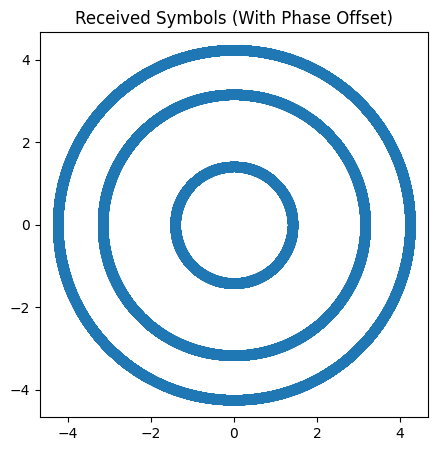

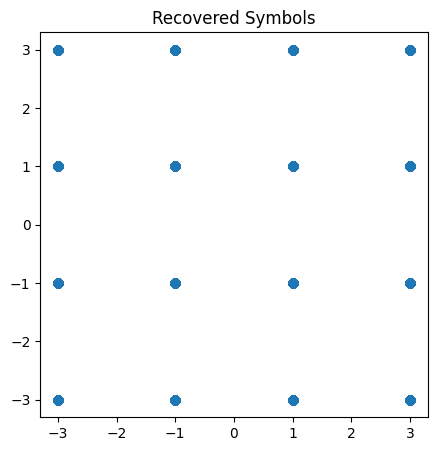

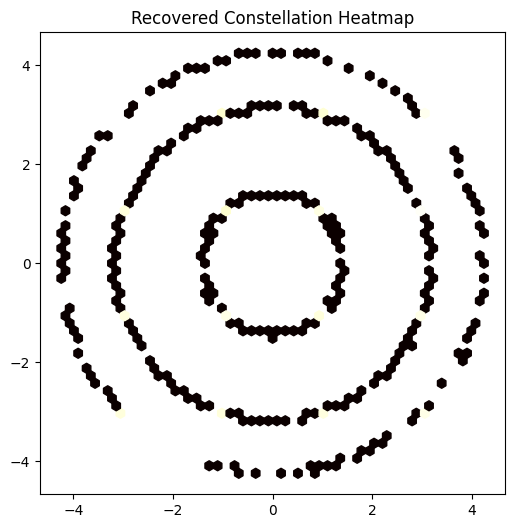

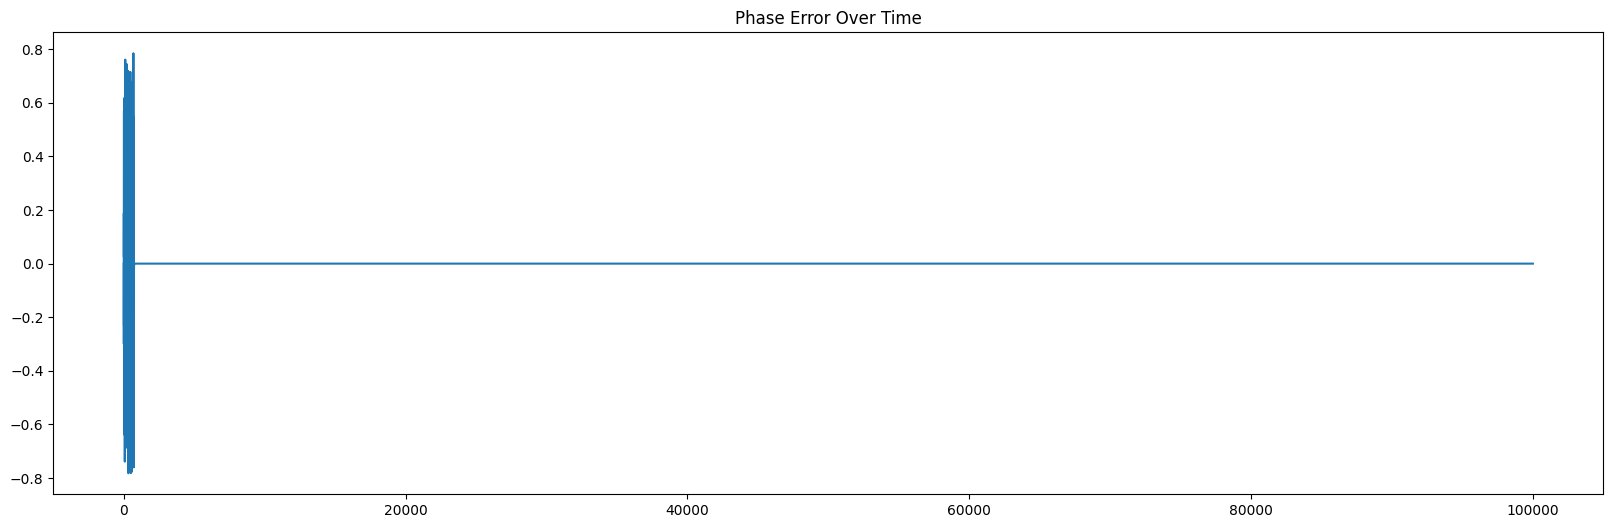

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 16-QAM constellation
qam16_constellation = {
    0: (-3, -3), 1: (-3, -1), 2: (-3, 1), 3: (-3, 3),
    4: (-1, -3), 5: (-1, -1), 6: (-1, 1), 7: (-1, 3),
    8: (1, -3), 9: (1, -1), 10: (1, 1), 11: (1, 3),
    12: (3, -3), 13: (3, -1), 14: (3, 1), 15: (3, 3)
}
symbols = np.array([complex(i, q) for i, q in qam16_constellation.values()])

# Inverse map for symbol decision
symbol_map = {v: k for k, v in qam16_constellation.items()}

# Signal parameters
n_samples = 100000
indices = np.random.randint(0, len(symbols), n_samples)
tx_symbols = symbols[indices]

# Apply frequency/phase offset
freq_offset = 10 * np.pi / 180  # ~10 degrees
n = np.arange(n_samples)
rx_symbols = tx_symbols * np.exp(1j * 2 * np.pi * freq_offset * n)

# Plot received constellation (distorted)
plt.figure(figsize=(5,5))
plt.title("Received Symbols (With Phase Offset)")
plt.scatter(np.real(rx_symbols), np.imag(rx_symbols)) 

# Carrier Recovery Loop
recovered_symbols = np.zeros(n_samples, dtype=complex)

Kp = 0.5  
Ki = 0.05 
zeta = Kp / (2 * np.sqrt(Ki))

print(f"Damping Ratio (ζ): {zeta}")
if(zeta < 1):
    print("Underdamped (Oscillatory Response): ζ<1")
elif (zeta == 1):
    print("Critically Damped (Fastest No-Overshoot Response): ζ=1")
else:
    print("Overdamped (Slow Response): ζ>1")

phase_nco = 0  
freq_nco = 0   
integrator = 0 
phase_errors = np.zeros(n_samples)

# Phase Tracking Loop
closest_indices = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    corrected_symbol = rx_symbols[i] * np.exp(-1j * phase_nco)

    closest_idx = np.argmin(abs(symbols - corrected_symbol))
    closest_symbol = symbols[closest_idx]
    phase_error = np.angle(corrected_symbol * np.conj(closest_symbol))

    phase_errors[i] = phase_error
    closest_indices[i] = closest_idx  # for BER

    integrator += Ki * phase_error  
    integrator = (integrator + np.pi) % (2 * np.pi) - np.pi  # Wrap [-π, π]
    
    freq_nco = Kp * phase_error + integrator          
    phase_nco += freq_nco  
    phase_nco = (phase_nco + np.pi) % (2 * np.pi) - np.pi  # Wrap [-π, π]
    
    recovered_symbols[i] = corrected_symbol

# Final Constellation Plot
plt.figure(figsize=(5,5))
plt.title("Recovered Symbols")
plt.scatter(np.real(recovered_symbols[800:]), np.imag(recovered_symbols[800:]))

plt.figure(figsize=(6, 6))
plt.title("Recovered Constellation Heatmap")
plt.hexbin(np.real(recovered_symbols), np.imag(recovered_symbols), gridsize=50, cmap="hot", mincnt=1)

# Plot phase error over time
plt.figure(figsize=(20,6))
plt.title("Phase Error Over Time")
plt.plot(range(n_samples), phase_errors)

# === Symbol Error Rate (SER), then BER from that ===
skip = 500  # symbols to ignore for loop convergence

rx_symbol_indices = closest_indices[skip:]
tx_symbol_indices = indices[skip:]

# Symbol Error Rate
symbol_errors = np.sum(rx_symbol_indices != tx_symbol_indices)
ser = symbol_errors / len(rx_symbol_indices)

# Convert to Bit Error Rate (assuming 4 bits per symbol and random errors)
ber = ser * 4 / np.log2(16)  # 16-QAM → 4 bits/symbol

print(f"\nSymbol Error Rate (SER): {ser:.6f}")
print(f"Estimated Bit Error Rate (BER): {ber:.6f}")


# === Phase Offset Measurement ===
# Average residual phase difference between original and corrected
phase_differences = np.angle(recovered_symbols * np.conj(tx_symbols))
avg_phase_error_rad = np.mean(phase_differences)
avg_phase_error_deg = np.degrees(avg_phase_error_rad)
print(f"Average Residual Phase Offset: {avg_phase_error_deg:.2f}°")

